# Total variance production

This notebook looks to explain variance production over a single timestep in two ANU-TUB configurations.
Both use a z-star vertical coordindate and both have background diffusivity $2\times 10^{-5}$.
The difference is in horizontal resolution: one is 0.25 and the is 1 degree.

In the 1 degree run, there is horizontal diffusion derived from MEKE whereas in the 0.25 degree run there is not.
We have alread shown that we can approximately balance the variance production between the advection scheme + mixing and surface forcing.
This notebook is trying to do the same thing for a whole day of output at both resolutions.

In [1]:
tub_output_dir = "/g/data/e14/jb2381/one-degree-anu-tub/output"
if pwd() != tub_output_dir 
    cd(tub_output_dir)
end
include("plotting.jl")

  Activating project at `/g/data/e14/jb2381/one-degree-anu-tub/output`
[ Info: Plotting and analysis environment setup!
[ Info: Experiments in the catalogue are: ("zstar", "hycom1", "adapt", "alt-hycom", "zstar-weaker-KD", "hycom1-weaker-KD", "adapt-weaker-KD", "alt-hycom-weaker-KD")
┌ Info: Available data is:
│           - daily
│           - monthly
│           - monthlyz
│           - monthlyrho2
│           - static
└           - vertical coordinate


In [2]:
quart_deg = "/g/data/e14/jb2381/anu-tub/outputs/anu-tub-nm-zstar/output016/ocean_hour.nc"
quart_static_deg = "/g/data/e14/jb2381/anu-tub/outputs/anu-tub-nm-zstar/output016/ocean_static.nc"
one_deg = joinpath(pwd(), "zstar/output057/ocean_hour.nc")
one_static_deg = joinpath(pwd(), "zstar/output057/ocean_static.nc")

"/g/data/e14/jb2381/one-degree-anu-tub/output/zstar/output057/ocean_static.nc"

In [3]:
"""
    function T_global_mean(output::AbstractString, static::AbstractString)
Compute the global mean of the temperature field at all timesteps in `output`.
"""
function T_global_mean(output::AbstractString, static::AbstractString)
    
    ds = NCDataset(static, maskingvalue=NaN)
    dA = ds["areacello"][:, :]
    wet = ds["wet"][:, :]
    close(ds)
    
    ds = NCDataset(output, maskingvalue=NaN)
    n = ds.dim["time"]
    θ̄ = zeros(Float64, n)
    for t ∈ 1:n
        θ = ds["thetao"][:, :, :, t]
        dV = ds["thkcello"][:, :, :, t]
        for k ∈ axes(dV, 3)
            dV[:, :, k] .*= dA
            dV[:, :, k] .*= wet
        end
        θ .*= dV
        θ̄[t] = nansum(θ) / nansum(dV)
    end
    close(ds)
    
    return dA, θ̄
end
function T_global_mean(output::AbstractString, dA::AbstractArray, wet::AbstractArray)
    
    ds = NCDataset(output, maskingvalue=NaN)
    n = ds.dim["time"]
    θ̄ = zeros(Float64, n)
    for t ∈ 1:n
        θ = ds["thetao"][:, :, :, t]
        dV = ds["thkcello"][:, :, :, t]
        for k ∈ axes(dV, 3)
            dV[:, :, k] .*= dA
            dV[:, :, k] .*= wet
        end
        θ .*= dV
        θ̄[t] = nansum(θ) / nansum(dV)
    end
    close(ds)
    
    return θ̄
end

T_global_mean (generic function with 2 methods)

In [4]:
"""
    function variance_production(output::AbstractString, static::AbstractString)
Return all variables contributing to variance production over a timestep. The variables
have been globally integrated so the balance between production and destruction can
be assessed.
"""
function variance_production(output::AbstractString, static::AbstractString; dt = 3600)
    
    vp = Dict{Any, Any}()
    
    ds = NCDataset(static, maskingvalue=NaN)
    dA = ds["areacello"][:, :]
    wet = ds["wet"][:, :]
    close(ds)
    
    vp["dA"] = dA
    θ̄ = T_global_mean(output, dA, wet)
    
    ds = NCDataset(output, maskingvalue=NaN)
    n = ds.dim["time"]-1
    asvp = zeros(Float64, n)
    diffvp = zeros(Float64, n)
    hordiffvp = zeros(Float64, n)
    remapvp = zeros(Float64, n)
    
    # thickness weighted variables
    for t ∈ 1:n
        _asvp = ds["T_advection_scheme_variance_production"][:, :, :, t+1]
        _diffvp = ds["T_diabatic_diff_var_prod"][:, :, :, t+1]
        _rempavp = ds["T_remap_variance_production"][:, :, :, t+1]
        _hordiffvp = ds["T_hordiff_variance_production"][:, :, :, t+1] # volume weighted
        for k ∈ axes(_asvp, 3)
            _asvp[:, :, k] .*= dA
            _diffvp[:, :, k] .*= dA
            _rempavp[:, :, k] .*= dA
        end
        asvp[t] = nansum(_asvp)
        diffvp[t] = nansum(_diffvp)
        remapvp[t] = nansum(_rempavp)
        hordiffvp[t] = nansum(_hordiffvp)
    end
    
    # offline calculations
    bfvp = zeros(Float64, n)
    total_var = zeros(Float64, n)
    for t ∈ 1:n
        # variance production from surface forcing
        dV_post_foricng = ds["boundary_forcing_h"][:, :, :, t+1] 
        dV_pre_forcing = dV_post_foricng .- dt*(ds["boundary_forcing_h_tendency"][:, :, :, t+1])
        dV_current_timestep = ds["thkcello"][:, :, :, t+1]
        dV_prev_timestep = ds["thkcello"][:, :, :, t]
        for k ∈ axes(dV_post_foricng, 3)
            dV_post_foricng[:, :, k] .*= dA
            dV_pre_forcing[:, :, k] .*= dA
            dV_current_timestep[:, :, k] .*= dA
            dV_prev_timestep[:, :, k] .*= dA
        end
        
        θ_predia = ds["temp_predia"][:, :, :, t+1]
        θ_post_forcing = θ_predia .+ dt*(ds["boundary_forcing_temp_tendency"][:, :, :, t+1])

        _bfvp = dV_post_foricng .* (θ_post_forcing .- θ̄[t+1]).^2 
        _bfvp .-= dV_pre_forcing .* (θ_predia .- θ̄[t]).^2

        bfvp[t] = nansum(_bfvp) ./ dt
        
        # total change in tmeperature variance over timestep
        _ΔVθ² = (ds["thetao"][:, :, :, t+1] .- θ̄[t+1]).^2
        _ΔVθ² .*= dV_current_timestep
        _ΔVθ² .-= (dV_prev_timestep.*(ds["thetao"][:, :, :, t] .- θ̄[t]).^2)
        _ΔVθ² ./= dt
        total_var[t] = nansum(_ΔVθ²)
    end
    
    vp["asvp"] = asvp
    vp["hordiffvp"] = hordiffvp
    vp["diffvp"] = diffvp
    vp["remapvp"] = remapvp
    vp["bfvp"] = bfvp
    vp["total_var"] = total_var
    vp["var_budget"] = asvp .+ remapvp .+ hordiffvp .+ diffvp .+ bfvp
    close(ds)
    
    return vp 
end

variance_production

## Quarter degree

In [ ]:
vp = variance_production(quart_deg, quart_static_deg)

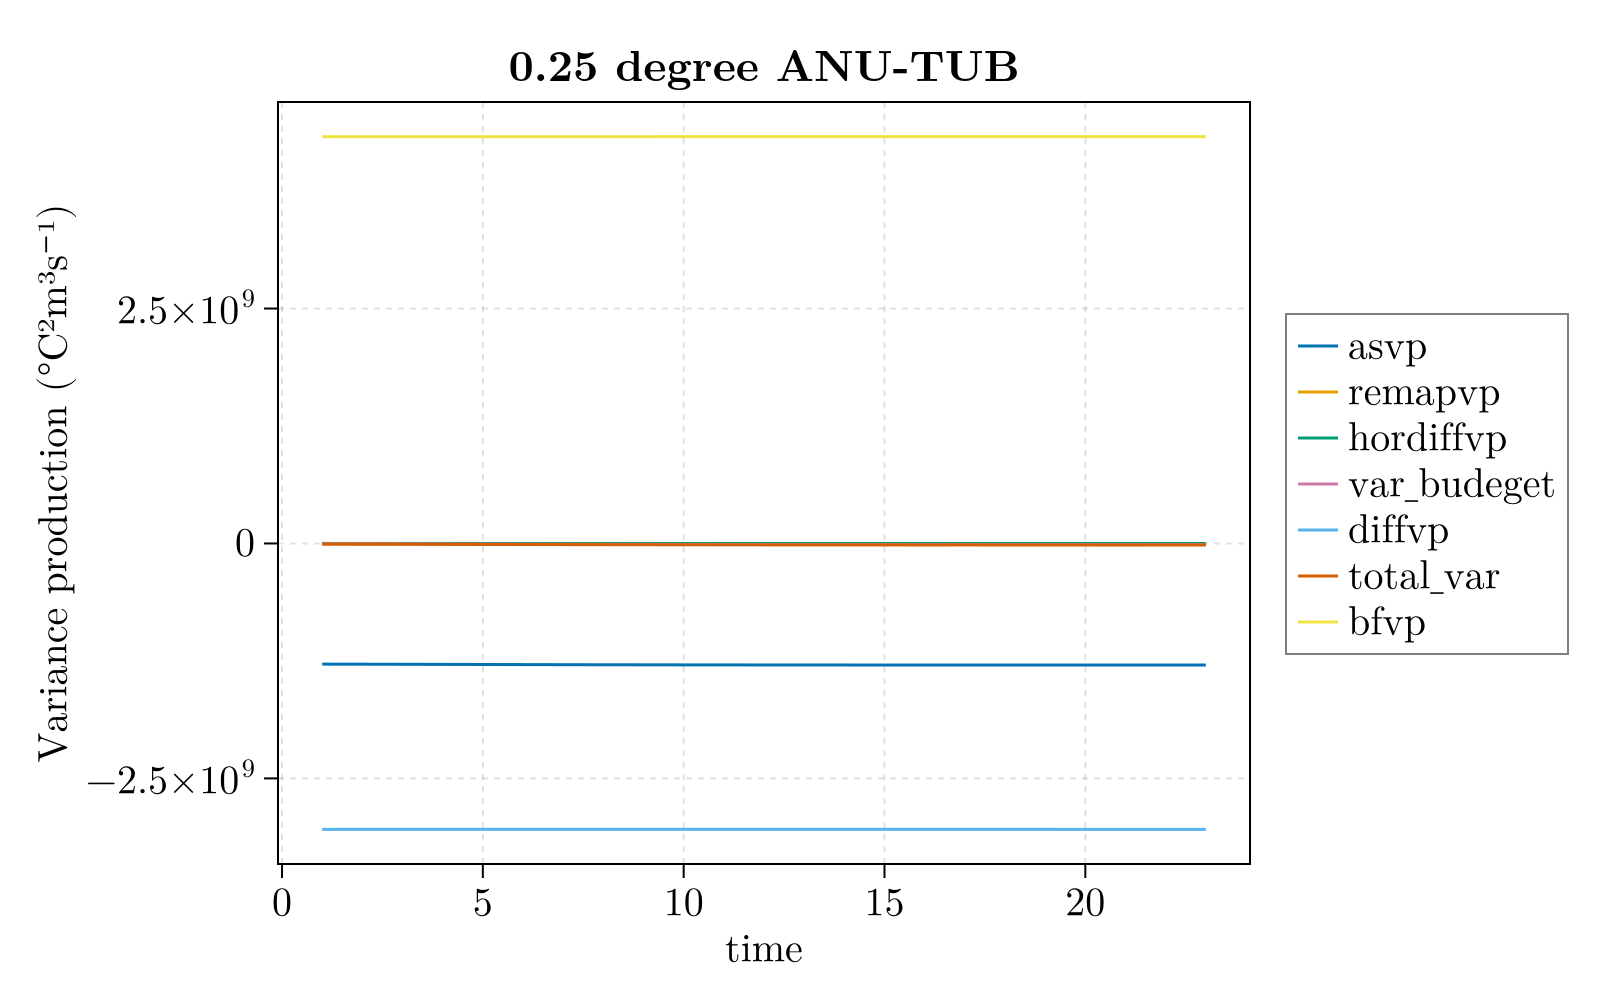

In [71]:
fig = Figure(size = (800, 500))
ax = Axis(fig[1, 1], xlabel = "time", ylabel = "Variance production (°C²m³s⁻¹)", title = "0.25 degree ANU-TUB")
for k ∈ keys(vp)
    if k != "dA"
        lines!(ax, vp[k], label = k)
    end
end
Legend(fig[1, 2], ax)
fig

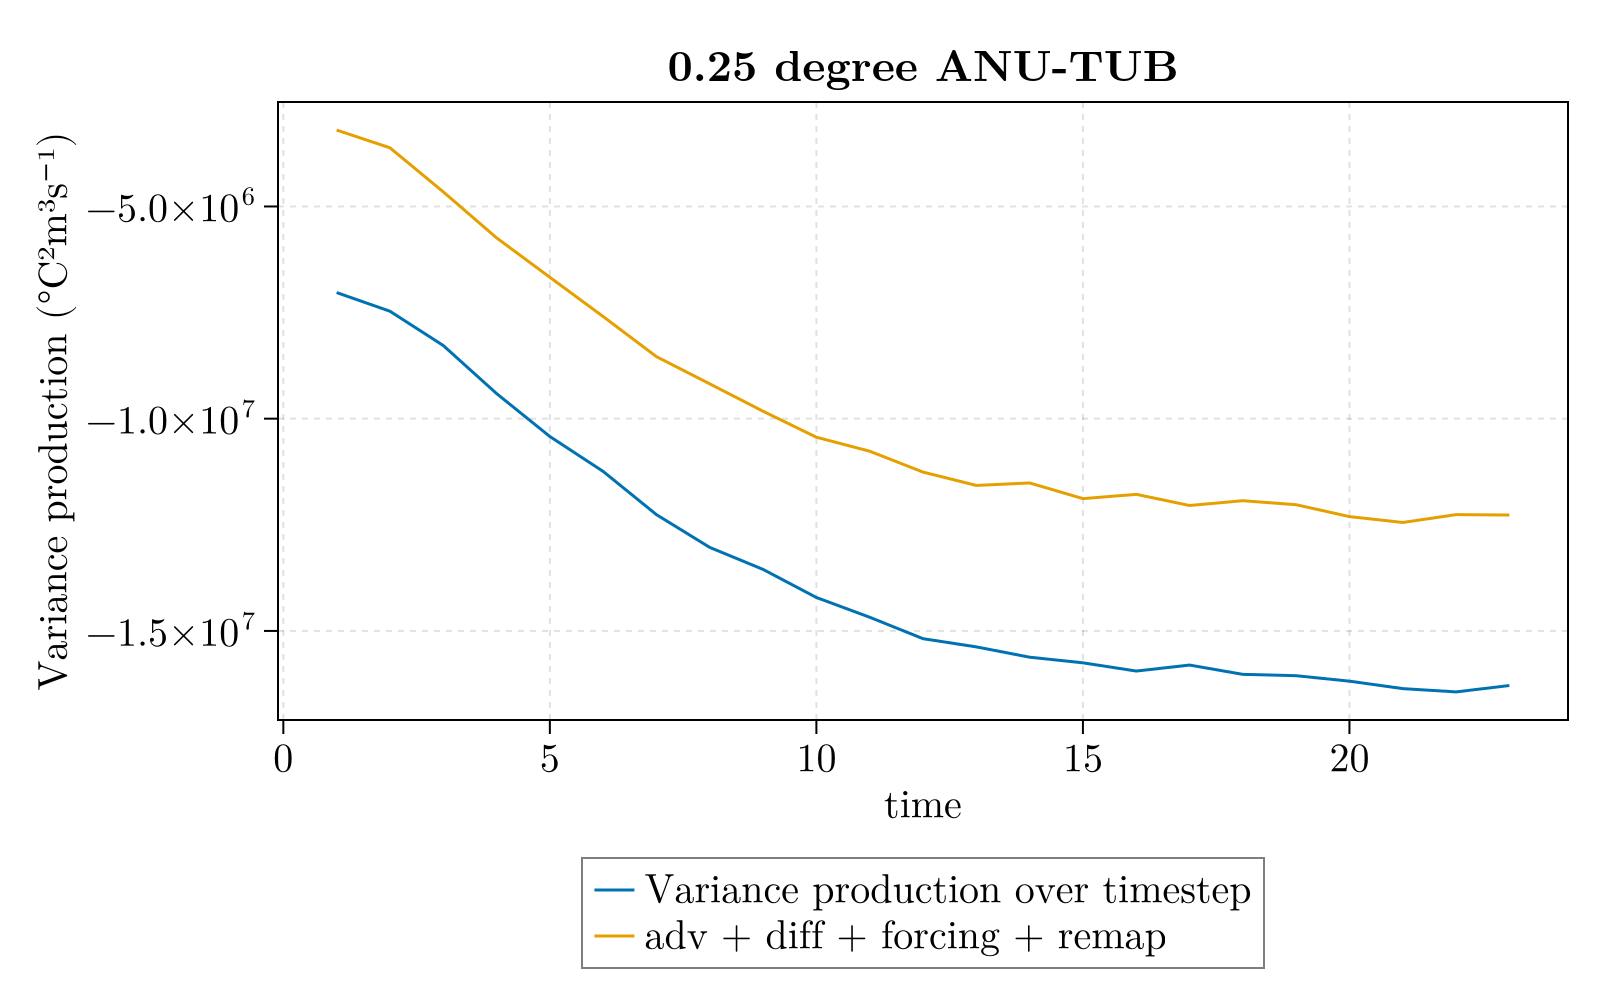

In [80]:
fig = Figure(size = (800, 500))
ax = Axis(fig[1, 1], xlabel = "time", ylabel = "Variance production (°C²m³s⁻¹)", title = "0.25 degree ANU-TUB")
lines!(ax, vp["total_var"], label = "Variance production over timestep")
lines!(ax, vp["var_budget"], label = "adv + diff + forcing + remap")
Legend(fig[2, 1], ax, orientation = :horizontal, nbanks = 2)
fig

## One degree

In [81]:
vp_od = variance_production(one_deg, one_static_deg)

Dict{Any, Any} with 8 entries:
  "asvp"       => [-6.34555e8, -6.37123e8, -6.36756e8, -6.38981e8, -6.38043e8, …
  "var_budget" => [4.69646e7, 4.34941e7, 4.44478e7, 4.21333e7, 4.31692e7, 4.499…
  "dA"         => [1.4463e9 1.49448e9 … 1.49448e9 1.4463e9; 1.4463e9 1.49448e9 …
  "remapvp"    => [-1.08039e6, -1.13638e6, -1.15329e6, -1.15587e6, -1.12385e6, …
  "hordiffvp"  => [-3.97613e8, -3.97614e8, -3.97615e8, -3.97612e8, -3.97609e8, …
  "diffvp"     => [-3.11036e9, -3.111e9, -3.11051e9, -3.11032e9, -3.11032e9, -3…
  "total_var"  => [4.43539e7, 4.11234e7, 4.12818e7, 3.95223e7, 3.97884e7, 4.138…
  "bfvp"       => [4.19058e9, 4.19037e9, 4.19048e9, 4.1902e9, 4.19026e9, 4.1900…

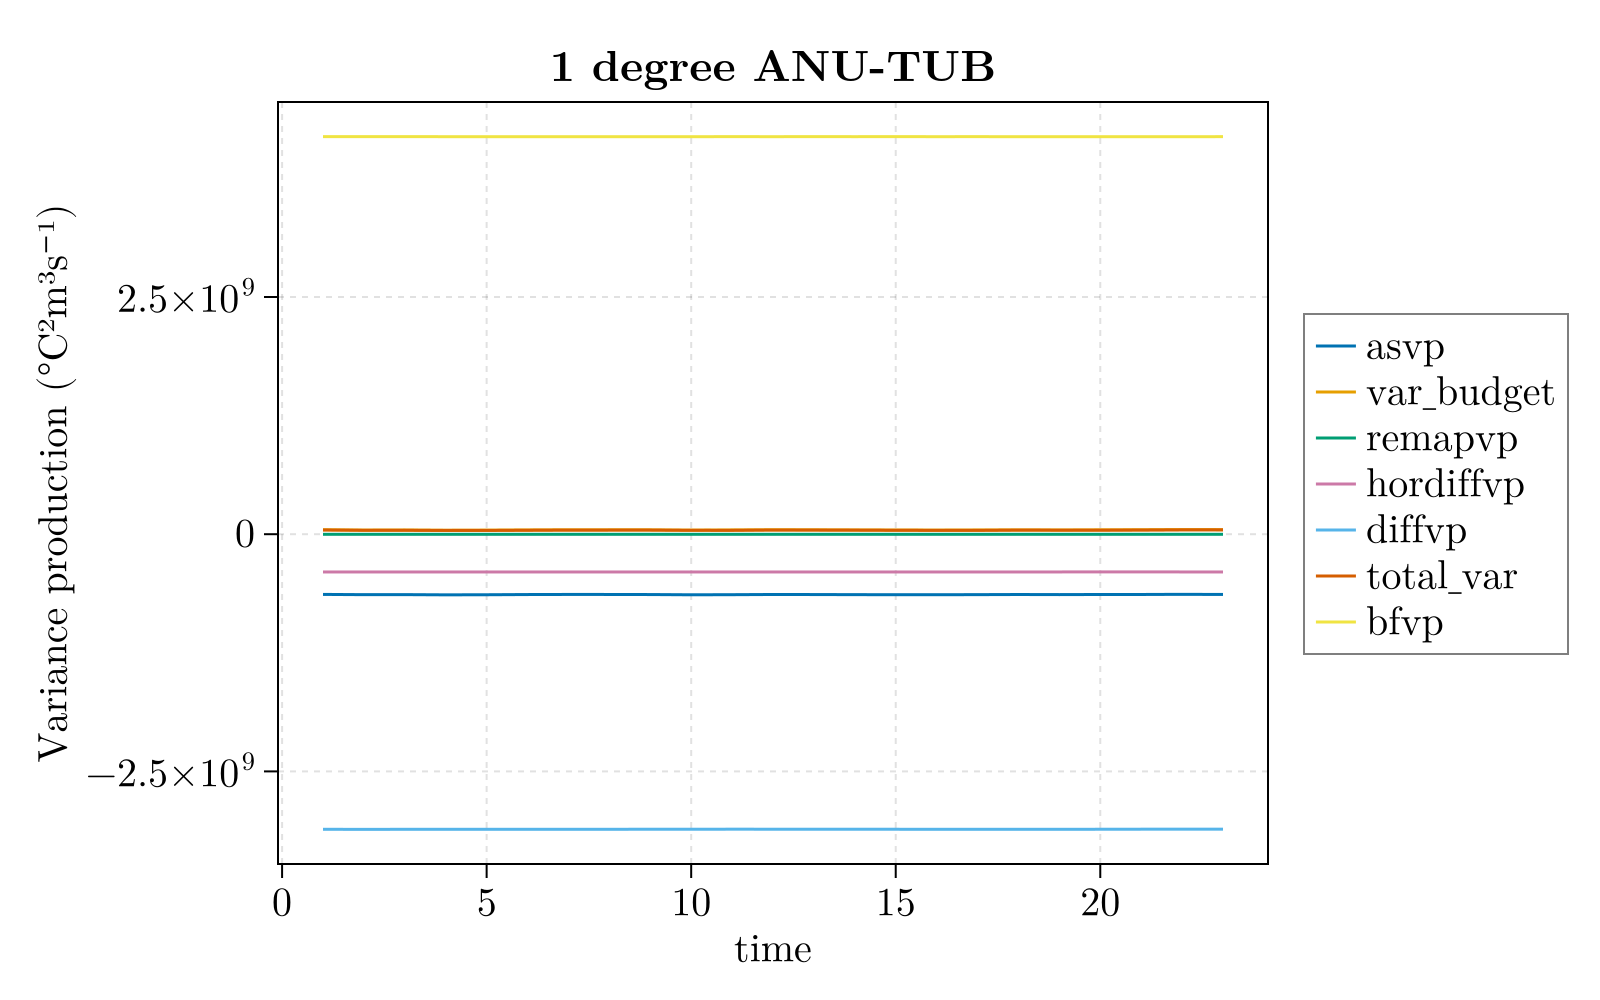

In [82]:
fig = Figure(size = (800, 500))
ax = Axis(fig[1, 1], xlabel = "time", ylabel = "Variance production (°C²m³s⁻¹)", title = "1 degree ANU-TUB")
for k ∈ keys(vp)
    if k != "dA"
        lines!(ax, vp_od[k], label = k)
    end
end
Legend(fig[1, 2], ax)
fig

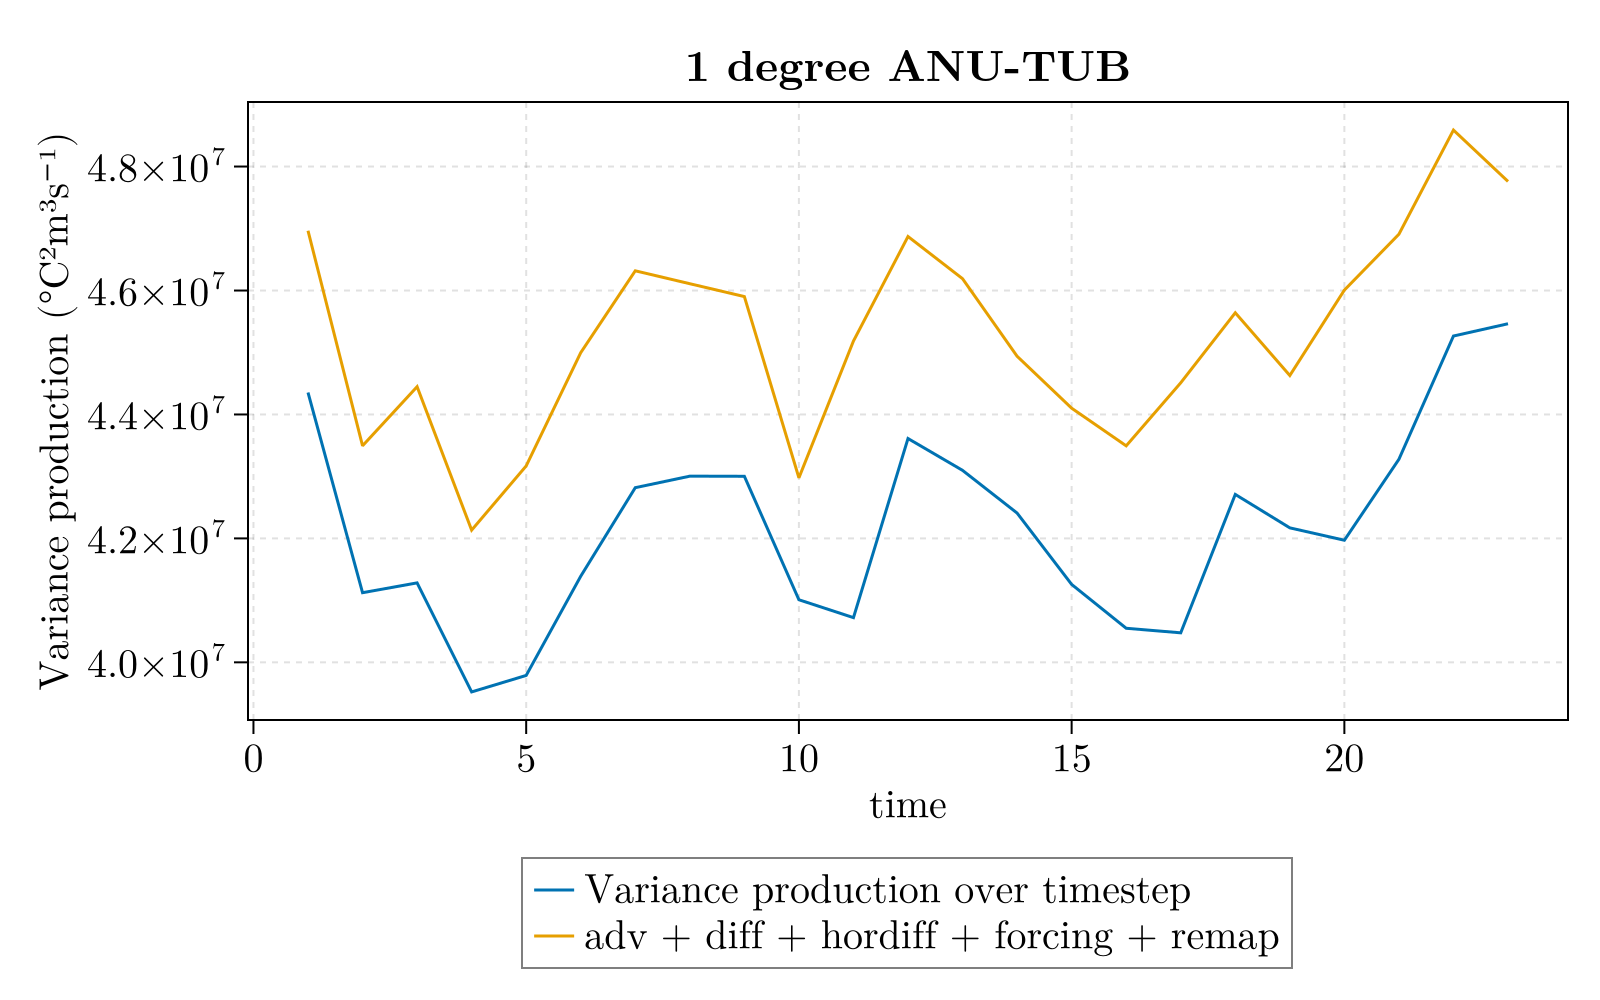

In [83]:
fig = Figure(size = (800, 500))
ax = Axis(fig[1, 1], xlabel = "time", ylabel = "Variance production (°C²m³s⁻¹)", title = "1 degree ANU-TUB")
lines!(ax, vp_od["total_var"], label = "Variance production over timestep")
rhs = vp_od["hordiffvp"] .+ vp_od["diffvp"] .+ vp_od["asvp"] .+ vp_od["remapvp"] .+ vp_od["bfvp"]
lines!(ax, rhs, label = "adv + diff + hordiff + forcing + remap")
Legend(fig[2, 1], ax, orientation = :horizontal, nbanks = 2)
fig

## Comparing the mean temperature

Within a current timestep we should have a pre and post forcing global mean temperture.
Corresponding to this are the values that are saved as timestep values.
Given it is only the forcing that should change the global mean, globally we should have:

- current timestep `thetao` = temperature post forcing
- previous timestep `thetao` = temperature pre forcing

The below aims to check this.

In [15]:
"""
    function T_global_mean_checks(output::AbstractString, static::AbstractString)
Compute the global mean temperature and different parts of the timestep field at all timesteps in `output`.
"""
function T_global_mean_checks(output::AbstractString, static::AbstractString)
    
    ds = NCDataset(static, maskingvalue=NaN)
    dA = ds["areacello"][:, :]
    close(ds)
    
    ds = NCDataset(output, maskingvalue=NaN)
    n = ds.dim["time"]
    θ̄ = zeros(Float64, n)
    θ̄_pre_forcing = zeros(Float64, n)
    θ̄_post_forcing = zeros(Float64, n)
    dt = 3600
    for t ∈ 1:n
        # timestep values
        θ = ds["thetao"][:, :, :, t]
        dV = ds["thkcello"][:, :, :, t]
        # pre and post forcing values
        dV_post_forcing = ds["boundary_forcing_h"][:, :, :, t] 
        dV_pre_forcing = dV_post_forcing .- dt*(ds["boundary_forcing_h_tendency"][:, :, :, t])
        θ_pre_forcing = ds["temp_predia"][:, :, :, t]
        θ_post_forcing = θ_pre_forcing .+ dt*(ds["boundary_forcing_temp_tendency"][:, :, :, t])

        for k ∈ axes(dV, 3)
            dV[:, :, k] .*= dA
            dV_pre_forcing[:, :, k] .*= dA
            dV_post_forcing[:, :, k] .*= dA
        end
        θ_pre_forcing .*= dV_pre_forcing
        θ_post_forcing .*= dV_post_forcing
        θ .*= dV
        θ̄[t] = nansum(θ) / nansum(dV)
        θ̄_pre_forcing[t] = nansum(θ_pre_forcing) / nansum(dV_pre_forcing)
        θ̄_post_forcing[t] = nansum(θ_post_forcing) / nansum(dV_post_forcing)
        
    end
    close(ds)
    
    mean_T = Dict{Any, Any}()
    
    mean_T["θ_timestep"] = θ̄
    mean_T["θ_pre_forcing"] = θ̄_pre_forcing
    mean_T["θ_post_forcing"] = θ̄_post_forcing
    
    return mean_T
end

T_global_mean_checks

In [16]:
T_global_mean_quart = T_global_mean_checks(quart_deg, quart_static_deg)
T_global_mean_one = T_global_mean_checks(one_deg, one_static_deg)

Dict{Any, Any} with 3 entries:
  "θ_timestep"     => [1.8248, 1.8248, 1.8248, 1.82479, 1.82479, 1.82479, 1.824…
  "θ_post_forcing" => [1.8248, 1.8248, 1.82479, 1.82479, 1.82479, 1.82479, 1.82…
  "θ_pre_forcing"  => [1.8248, 1.8248, 1.8248, 1.82479, 1.82479, 1.82479, 1.824…

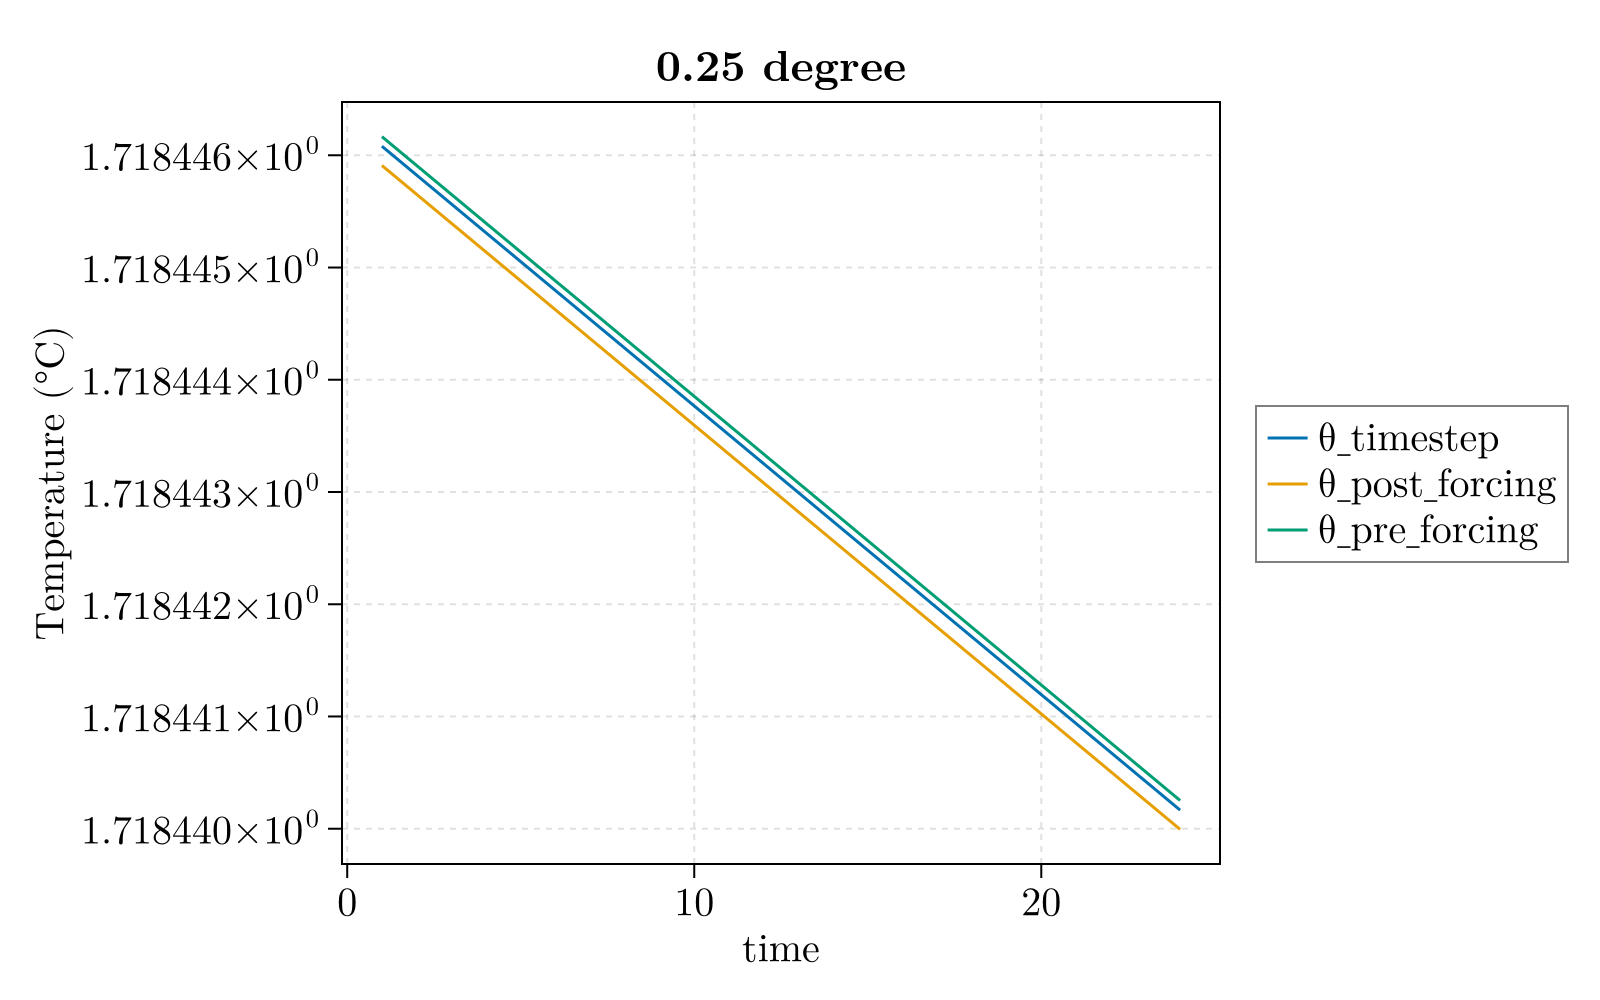

In [11]:
fig = Figure(size = (800, 500))
ax = Axis(fig[1, 1], xlabel = "time", ylabel = "Temperature (°C)", title = "0.25 degree")
for k ∈ keys(T_global_mean_quart)
        lines!(ax, T_global_mean_quart[k], label = k)
end
Legend(fig[1, 2], ax)
fig

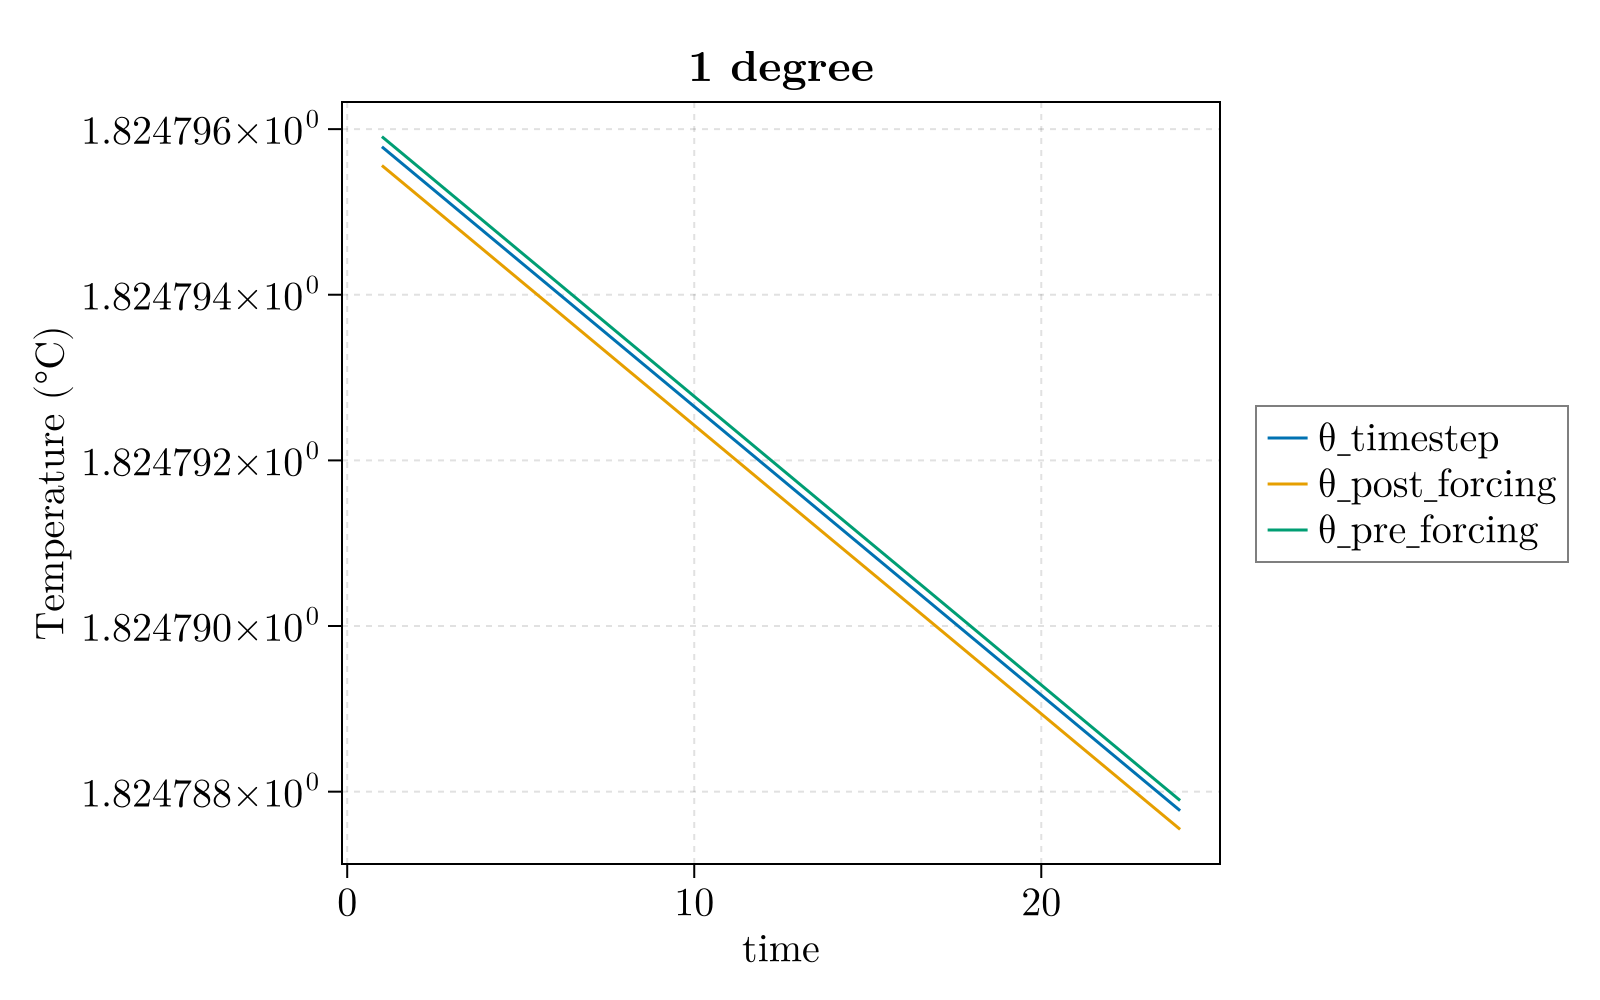

In [12]:
fig = Figure(size = (800, 500))
ax = Axis(fig[1, 1], xlabel = "time", ylabel = "Temperature (°C)", title = "1 degree")
for k ∈ keys(T_global_mean_one)
        lines!(ax, T_global_mean_one[k], label = k)
end
Legend(fig[1, 2], ax)
fig